# Data Preprocessing

### Import libraries

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

### Create project paths

In [5]:
# The notebook is inside the notebooks folder
raw_data_path = Path("../data/raw/framingham.csv")
processed_data_folder = Path("../data/processed")

# Create the processed-data folder if it does not already exist
processed_data_folder.mkdir(parents=True, exist_ok=True)

print("Raw data path:")
print(raw_data_path.resolve())

print("\nProcessed data folder:")
print(processed_data_folder.resolve())

Raw data path:
/Volumes/GraceHardDrive/aml_final_project/data/raw/framingham.csv

Processed data folder:
/Volumes/GraceHardDrive/aml_final_project/data/processed


### Load dataset

In [8]:
df = pd.read_csv(raw_data_path)

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### Standardize column names

In [9]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


### Remove duplicate rows (no duplicate rows)

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Check missing values

In [11]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_values = missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
glucose,388,9.16
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02


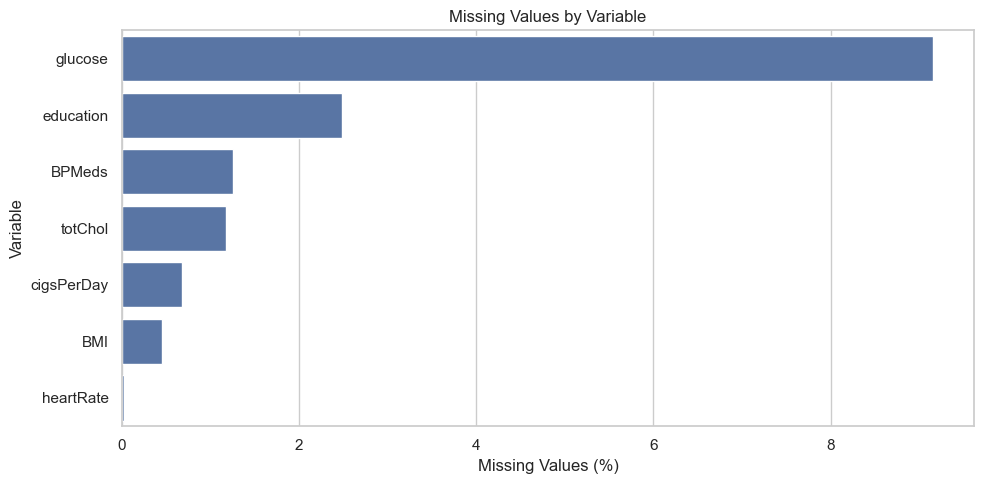

In [12]:
if not missing_values.empty:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=missing_values.reset_index(),
        x="Missing Percentage",
        y="index"
    )

    plt.title("Missing Values by Variable")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values were found.")

### Check the target variable

In [13]:
target_column = "TenYearCHD"

if target_column not in df.columns:
    raise KeyError(
        f"{target_column} was not found in the dataset."
    )

print(df[target_column].value_counts(dropna=False))

TenYearCHD
0    3594
1     644
Name: count, dtype: int64


In [14]:
print(
    "Missing target values:",
    df[target_column].isnull().sum()
)

df = df.dropna(
    subset=[target_column]
).reset_index(drop=True)

Missing target values: 0


### Check invalid target values

In [15]:
print(
    "Unique target values:",
    sorted(df[target_column].unique())
)

Unique target values: [0, 1]


In [16]:
valid_target_values = {0, 1}
observed_target_values = set(
    df[target_column].unique()
)

if not observed_target_values.issubset(
    valid_target_values
):
    raise ValueError(
        f"Unexpected target values found: "
        f"{observed_target_values}"
    )

### Identify feature types

In [17]:
binary_columns = [
    "male",
    "currentSmoker",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes"
]

ordinal_columns = [
    "education"
]

continuous_columns = [
    "age",
    "cigsPerDay",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

In [18]:
binary_columns = [
    column for column in binary_columns
    if column in df.columns
]

ordinal_columns = [
    column for column in ordinal_columns
    if column in df.columns
]

continuous_columns = [
    column for column in continuous_columns
    if column in df.columns
]

print("Binary columns:")
print(binary_columns)

print("\nOrdinal columns:")
print(ordinal_columns)

print("\nContinuous columns:")
print(continuous_columns)

Binary columns:
['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

Ordinal columns:
['education']

Continuous columns:
['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


### Inspect categorical and binary values

In [19]:
categorical_columns = (
    binary_columns + ordinal_columns
)

for column in categorical_columns:
    print(f"\n{column}")
    print(
        df[column]
        .value_counts(dropna=False)
        .sort_index()
    )


male
male
0    2419
1    1819
Name: count, dtype: int64

currentSmoker
currentSmoker
0    2144
1    2094
Name: count, dtype: int64

BPMeds
BPMeds
0.0    4061
1.0     124
NaN      53
Name: count, dtype: int64

prevalentStroke
prevalentStroke
0    4213
1      25
Name: count, dtype: int64

prevalentHyp
prevalentHyp
0    2922
1    1316
Name: count, dtype: int64

diabetes
diabetes
0    4129
1     109
Name: count, dtype: int64

education
education
1.0    1720
2.0    1253
3.0     687
4.0     473
NaN     105
Name: count, dtype: int64


### Separate predictors and target

In [20]:
X = df.drop(columns=[target_column])
y = df[target_column].astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (4238, 15)
Target shape: (4238,)


In [21]:
X.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [22]:
y.head()

0    0
1    0
2    0
3    1
4    0
Name: TenYearCHD, dtype: int64

### Examine target balance

In [23]:
target_summary = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

target_summary.index = [
    "No CHD",
    "CHD"
]

target_summary

,Count,Percentage
No CHD,3594,84.8
CHD,644,15.2


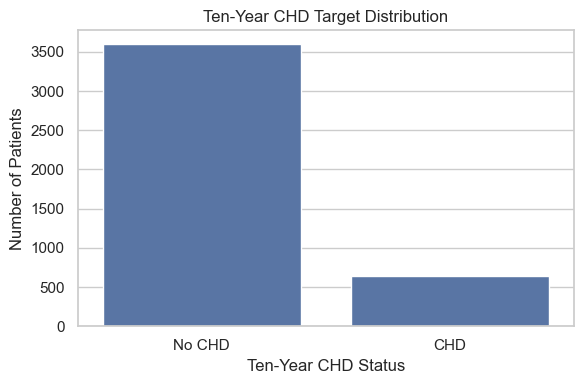

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target_column
)

plt.title("Ten-Year CHD Target Distribution")
plt.xlabel("Ten-Year CHD Status")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0, 1],
    labels=["No CHD", "CHD"]
)

plt.tight_layout()
plt.show()

### Split into training and testing sets

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3390, 15)
X_test shape: (848, 15)
y_train shape: (3390,)
y_test shape: (848,)


### Confirm class balance after splitting

In [26]:
print("Training target distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nTesting target distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Training target distribution:
TenYearCHD
0    0.8481
1    0.1519
Name: proportion, dtype: float64

Testing target distribution:
TenYearCHD
0    0.8479
1    0.1521
Name: proportion, dtype: float64


### Create copies before preprocessing

In [27]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

### Impute continuous variables

In [28]:
continuous_imputer = SimpleImputer(
    strategy="median"
)

X_train_clean[continuous_columns] = (
    continuous_imputer.fit_transform(
        X_train[continuous_columns]
    )
)

X_test_clean[continuous_columns] = (
    continuous_imputer.transform(
        X_test[continuous_columns]
    )
)

### Impute binary and ordinal variables

In [ ]:
categorical_columns = binary_columns + ordinal_columns

categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_clean[categorical_columns] = categorical_imputer.fit_transform(
    X_train[categorical_columns]
)

X_test_clean[categorical_columns] = categorical_imputer.transform(
    X_test[categorical_columns]
)

### Verify that missing values are gone

In [30]:
print(
    "Missing values in training set:",
    X_train_clean.isnull().sum().sum()
)

print(
    "Missing values in testing set:",
    X_test_clean.isnull().sum().sum()
)

Missing values in training set: 0
Missing values in testing set: 0


### Detailed check

In [ ]:
remaining_missing = pd.DataFrame({
    "Training Missing":
        X_train_clean.isnull().sum(),

    "Testing Missing":
        X_test_clean.isnull().sum()
})

remaining_missing[
    (remaining_missing["Training Missing"] > 0)
    |
    (remaining_missing["Testing Missing"] > 0)
]

# Standard Scaling

### Create standardized datasets

In [32]:
standard_scaler = StandardScaler()

X_train_standard = X_train_clean.copy()
X_test_standard = X_test_clean.copy()

In [33]:
X_train_standard[continuous_columns] = (
    standard_scaler.fit_transform(
        X_train_clean[continuous_columns]
    )
)

X_test_standard[continuous_columns] = (
    standard_scaler.transform(
        X_test_clean[continuous_columns]
    )
)

In [34]:
X_train_standard.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
1767,0.0,0.160422,2.0,0.0,-0.751499,0.0,0.0,0.0,0.0,1.109942,0.187178,0.308956,-0.244064,-0.492725,0.060544
2947,0.0,1.094437,2.0,0.0,-0.751499,0.0,0.0,0.0,0.0,0.973412,-0.017371,0.435256,0.161465,0.173113,0.277917
888,1.0,0.860933,1.0,1.0,0.084843,0.0,0.0,1.0,0.0,-0.687694,0.391726,0.014257,0.525713,-1.075334,-0.548101
2026,1.0,-1.707608,2.0,1.0,-0.500596,0.0,0.0,1.0,0.0,1.041677,-0.971931,0.098457,0.875391,0.339573,-0.156829
2696,0.0,-0.773593,1.0,1.0,0.503014,0.0,0.0,0.0,0.0,1.792588,0.005357,-0.533042,1.390195,1.588020,-0.156829


### Verify standard scaling

In [35]:
standard_scaling_summary = pd.DataFrame({
    "Mean":
        X_train_standard[
            continuous_columns
        ].mean(),

    "Standard Deviation":
        X_train_standard[
            continuous_columns
        ].std(ddof=0)
})

standard_scaling_summary.round(3)

,Mean,Standard Deviation
age,-0.0,1.0
cigsPerDay,0.0,1.0
totChol,-0.0,1.0
sysBP,-0.0,1.0
diaBP,0.0,1.0
BMI,-0.0,1.0
heartRate,-0.0,1.0
glucose,-0.0,1.0


# Min-Max Scaling

### Create min-max scaled datasets

In [36]:
minmax_scaler = MinMaxScaler()

X_train_minmax = X_train_clean.copy()
X_test_minmax = X_test_clean.copy()

In [37]:
X_train_minmax[continuous_columns] = (
    minmax_scaler.fit_transform(
        X_train_clean[continuous_columns]
    )
)

X_test_minmax[continuous_columns] = (
    minmax_scaler.transform(
        X_test_clean[continuous_columns]
    )
)

In [38]:
X_train_minmax.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
1767,0.0,0.500000,2.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.361055,0.250591,0.437500,0.224673,0.262626,0.121469
2947,0.0,0.710526,2.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.348884,0.229314,0.454545,0.265148,0.343434,0.135593
888,1.0,0.657895,1.0,1.0,0.142857,0.0,0.0,1.0,0.0,0.200811,0.271868,0.397727,0.301503,0.191919,0.081921
2026,1.0,0.078947,2.0,1.0,0.042857,0.0,0.0,1.0,0.0,0.354970,0.130024,0.409091,0.336403,0.363636,0.107345
2696,0.0,0.289474,1.0,1.0,0.214286,0.0,0.0,0.0,0.0,0.421907,0.231678,0.323864,0.387785,0.515152,0.107345


### Verify

In [39]:
minmax_scaling_summary = pd.DataFrame({
    "Minimum":
        X_train_minmax[
            continuous_columns
        ].min(),

    "Maximum":
        X_train_minmax[
            continuous_columns
        ].max()
})

minmax_scaling_summary.round(3)

,Minimum,Maximum
age,0.0,1.0
cigsPerDay,0.0,1.0
totChol,0.0,1.0
sysBP,0.0,1.0
diaBP,0.0,1.0
BMI,0.0,1.0
heartRate,0.0,1.0
glucose,0.0,1.0


### Compare unscaled and scaled values

In [40]:
example_columns = [
    column for column in [
        "age",
        "sysBP",
        "BMI",
        "glucose"
    ]
    if column in continuous_columns
]

scaling_comparison = pd.concat(
    [
        X_train_clean[
            example_columns
        ].head().add_suffix("_original"),

        X_train_standard[
            example_columns
        ].head().add_suffix("_standard"),

        X_train_minmax[
            example_columns
        ].head().add_suffix("_minmax")
    ],
    axis=1
)

scaling_comparison

,age_original,sysBP_original,BMI_original,glucose_original,age_standard,sysBP_standard,BMI_standard,glucose_standard,age_minmax,sysBP_minmax,BMI_minmax,glucose_minmax
1767,51.0,136.5,24.81,83.0,0.160422,0.187178,-0.244064,0.060544,0.500000,0.250591,0.224673,0.121469
2947,59.0,132.0,26.48,88.0,1.094437,-0.017371,0.161465,0.277917,0.710526,0.229314,0.265148,0.135593
888,57.0,141.0,27.98,69.0,0.860933,0.391726,0.525713,-0.548101,0.657895,0.271868,0.301503,0.081921
2026,35.0,111.0,29.42,78.0,-1.707608,-0.971931,0.875391,-0.156829,0.078947,0.130024,0.336403,0.107345
2696,43.0,132.5,31.54,78.0,-0.773593,0.005357,1.390195,-0.156829,0.289474,0.231678,0.387785,0.107345


## Save processed data

### Reset indices before saving

In [41]:
X_train_clean = (
    X_train_clean.reset_index(drop=True)
)

X_test_clean = (
    X_test_clean.reset_index(drop=True)
)

X_train_standard = (
    X_train_standard.reset_index(drop=True)
)

X_test_standard = (
    X_test_standard.reset_index(drop=True)
)

X_train_minmax = (
    X_train_minmax.reset_index(drop=True)
)

X_test_minmax = (
    X_test_minmax.reset_index(drop=True)
)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

### Save unscaled cleaned data

In [42]:
X_train_clean.to_csv(
    processed_data_folder / "X_train_clean.csv",
    index=False
)

X_test_clean.to_csv(
    processed_data_folder / "X_test_clean.csv",
    index=False
)

### Save standardized data

In [43]:
X_train_standard.to_csv(
    processed_data_folder /
    "X_train_standard.csv",
    index=False
)

X_test_standard.to_csv(
    processed_data_folder /
    "X_test_standard.csv",
    index=False
)

### Save min-max scaled data

In [44]:
X_train_minmax.to_csv(
    processed_data_folder /
    "X_train_minmax.csv",
    index=False
)

X_test_minmax.to_csv(
    processed_data_folder /
    "X_test_minmax.csv",
    index=False
)

### Save target datasets

In [47]:
y_train.to_csv(
    processed_data_folder / "y_train.csv",
    index=False
)

y_test.to_csv(
    processed_data_folder / "y_test.csv",
    index=False
)

### Create complete training and testing datasets

In [48]:
train_clean = X_train_clean.copy()
test_clean = X_test_clean.copy()

train_clean[target_column] = y_train
test_clean[target_column] = y_test

In [49]:
train_clean.to_csv(
    processed_data_folder / "train_clean.csv",
    index=False
)

test_clean.to_csv(
    processed_data_folder / "test_clean.csv",
    index=False
)

In [50]:
train_standard = X_train_standard.copy()
test_standard = X_test_standard.copy()

train_standard[target_column] = y_train
test_standard[target_column] = y_test

In [51]:
train_standard.to_csv(
    processed_data_folder /
    "train_standard.csv",
    index=False
)

test_standard.to_csv(
    processed_data_folder /
    "test_standard.csv",
    index=False
)

In [52]:
train_minmax = X_train_minmax.copy()
test_minmax = X_test_minmax.copy()

train_minmax[target_column] = y_train
test_minmax[target_column] = y_test

In [53]:
train_minmax.to_csv(
    processed_data_folder /
    "train_minmax.csv",
    index=False
)

test_minmax.to_csv(
    processed_data_folder /
    "test_minmax.csv",
    index=False
)

In [54]:
print("Saved processed files:\n")

for file_path in sorted(
    processed_data_folder.glob("*.csv")
):
    print(file_path.name)

Saved processed files:

X_test_clean.csv
X_test_minmax.csv
X_test_standard.csv
X_train_clean.csv
X_train_minmax.csv
X_train_standard.csv
test_clean.csv
test_minmax.csv
test_standard.csv
train_clean.csv
train_minmax.csv
train_standard.csv
y_test.csv
y_train.csv


In [55]:
preprocessing_summary = pd.DataFrame({
    "Dataset": [
        "Full cleaned dataset",
        "Training set",
        "Testing set"
    ],

    "Rows": [
        len(df),
        len(X_train_clean),
        len(X_test_clean)
    ],

    "Predictors": [
        X.shape[1],
        X_train_clean.shape[1],
        X_test_clean.shape[1]
    ],

    "Remaining Missing Values": [
        df.drop(
            columns=[target_column]
        ).isnull().sum().sum(),

        X_train_clean.isnull().sum().sum(),

        X_test_clean.isnull().sum().sum()
    ]
})

preprocessing_summary

,Dataset,Rows,Predictors,Remaining Missing Values
0,Full cleaned dataset,4238,15,645
1,Training set,3390,15,0
2,Testing set,848,15,0
